# Pose Classifier — Model Evaluation
Evaluates `pose_classifier_best.pt` on the held-out **test** split.  
Outputs: accuracy, per-class metrics, confusion matrix, confidence distributions.

In [1]:
import os
import json
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded ✅')

Libraries loaded ✅


## Config

In [2]:
DATA_ROOT      = 'keypoints_json'
CHECKPOINT     = 'pose_classifier_best.pt'   # swap to pose_classifier_final.pt to compare
BATCH_SIZE     = 64
DEVICE         = 'mps' if torch.backends.mps.is_available() else 'cpu'

CLASS_MAP = {
    'spike':   0,
    'defense': 1,
    'block':   2,
    'set':     3,
    'serve':   4
}
IDX_TO_CLASS = {v: k for k, v in CLASS_MAP.items()}
CLASS_NAMES  = [IDX_TO_CLASS[i] for i in range(len(CLASS_MAP))]

print(f'Device: {DEVICE}')
print(f'Checkpoint: {CHECKPOINT}')
print(f'Classes: {CLASS_NAMES}')

Device: mps
Checkpoint: pose_classifier_best.pt
Classes: ['spike', 'defense', 'block', 'set', 'serve']


## Feature Engineering (must match train.py exactly)

In [3]:
def get_angle(a, b, c):
    ba = a - b
    bc = c - b
    cos_angle = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-6)
    return np.arccos(np.clip(cos_angle, -1.0, 1.0))


def normalize_keypoints(kp):
    kp = np.array(kp)
    xy   = kp[:, :2]
    conf = kp[:, 2:]

    xy[conf.squeeze() < 0.3] = 0

    center = (xy[11] + xy[12]) / 2
    xy = xy - center

    torso = np.linalg.norm((xy[5] + xy[6]) / 2)
    if torso > 0:
        xy = xy / torso

    if xy[6][0] < xy[5][0]:
        xy[:, 0] *= -1

    angles = []
    angles.append(get_angle(xy[5],  xy[7],  xy[9]))   # left elbow
    angles.append(get_angle(xy[6],  xy[8],  xy[10]))  # right elbow
    angles.append(get_angle(xy[11], xy[13], xy[15]))  # left knee
    angles.append(get_angle(xy[12], xy[14], xy[16]))  # right knee
    angles.append(get_angle(xy[7],  xy[5],  xy[11]))  # left shoulder
    angles.append(get_angle(xy[8],  xy[6],  xy[12]))  # right shoulder

    return np.concatenate([xy.flatten(), conf.flatten(), np.array(angles)])


print('Feature functions defined ✅')

Feature functions defined ✅


## Dataset & Model

In [4]:
class PoseDataset(Dataset):
    def __init__(self, split):
        self.samples = []
        split_dir = os.path.join(DATA_ROOT, split)

        for class_name in CLASS_MAP:
            class_dir = os.path.join(split_dir, class_name)
            if not os.path.exists(class_dir):
                continue
            for file in os.listdir(class_dir):
                if file.endswith('.json'):
                    self.samples.append((
                        os.path.join(class_dir, file),
                        CLASS_MAP[class_name]
                    ))

        counts = Counter(s[1] for s in self.samples)
        print(f'{split} split — {len(self.samples)} samples')
        for i, name in IDX_TO_CLASS.items():
            print(f'  {name}: {counts.get(i, 0)}')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        with open(path) as f:
            data = json.load(f)
        kp = normalize_keypoints(data['keypoints'])
        return torch.tensor(kp, dtype=torch.float32), torch.tensor(label)


class PoseClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(57, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 5)
        )

    def forward(self, x):
        return self.net(x)

## Load Checkpoint & Test Data

In [5]:
test_dataset = PoseDataset('test')
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

model = PoseClassifier().to(DEVICE)
model.load_state_dict(torch.load(CHECKPOINT, map_location=DEVICE))
model.eval()
print(f'\nLoaded {CHECKPOINT} ✅')

test split — 707 samples
  spike: 220
  defense: 15
  block: 205
  set: 164
  serve: 103

Loaded pose_classifier_best.pt ✅


## Run Inference

In [6]:
all_preds   = []
all_labels  = []
all_probs   = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE)
        logits = model(x)
        probs  = torch.softmax(logits, dim=1)
        preds  = probs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

accuracy = (all_preds == all_labels).mean()
print(f'\nTest Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)')


Test Accuracy: 0.5290 (52.90%)


## Classification Report

In [7]:
print(classification_report(
    all_labels, all_preds,
    target_names=CLASS_NAMES,
    digits=4
))

              precision    recall  f1-score   support

       spike     0.6957    0.3636    0.4776       220
     defense     0.1875    0.6000    0.2857        15
       block     0.5242    0.6341    0.5740       205
         set     0.5102    0.6098    0.5556       164
       serve     0.5500    0.5340    0.5419       103

    accuracy                         0.5290       707
   macro avg     0.4935    0.5483    0.4869       707
weighted avg     0.5709    0.5290    0.5289       707



## Confusion Matrix

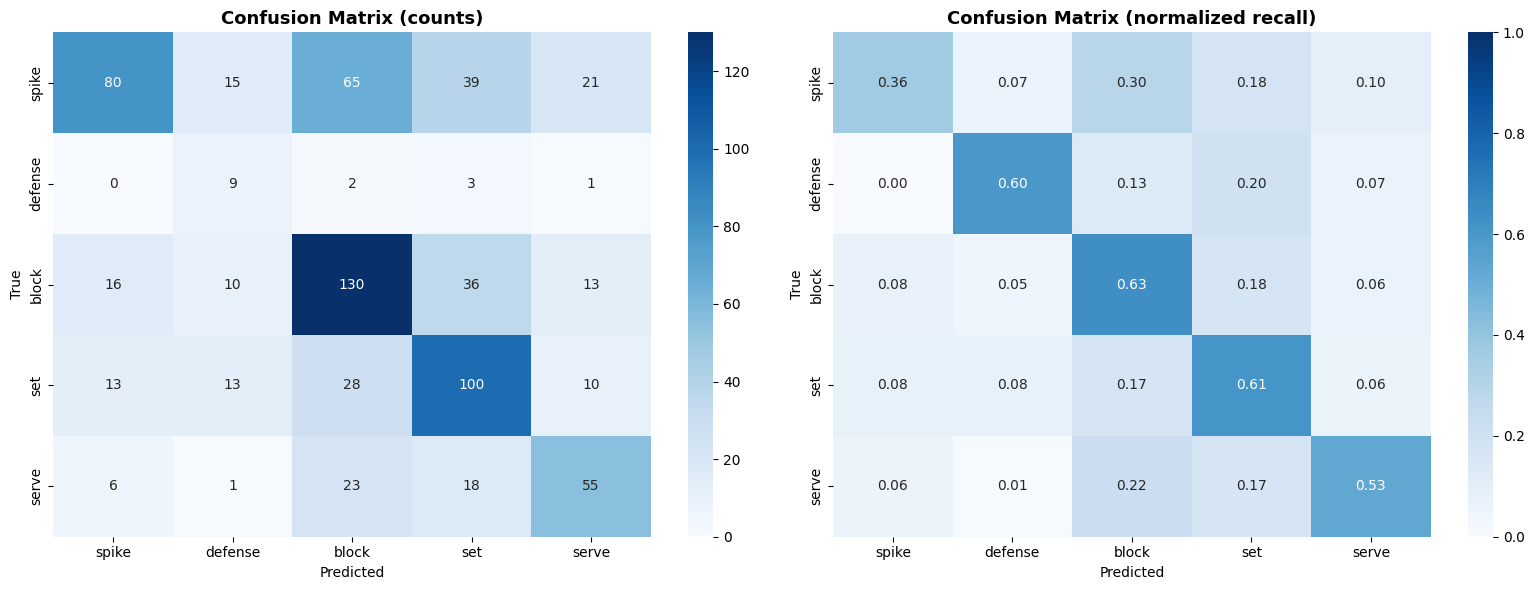

Saved → confusion_matrix.png


In [8]:
cm = confusion_matrix(all_labels, all_preds)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix (counts)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# Normalized (recall per class)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(
    cm_norm, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    vmin=0, vmax=1, ax=axes[1]
)
axes[1].set_title('Confusion Matrix (normalized recall)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → confusion_matrix.png')

## Per-Class Accuracy

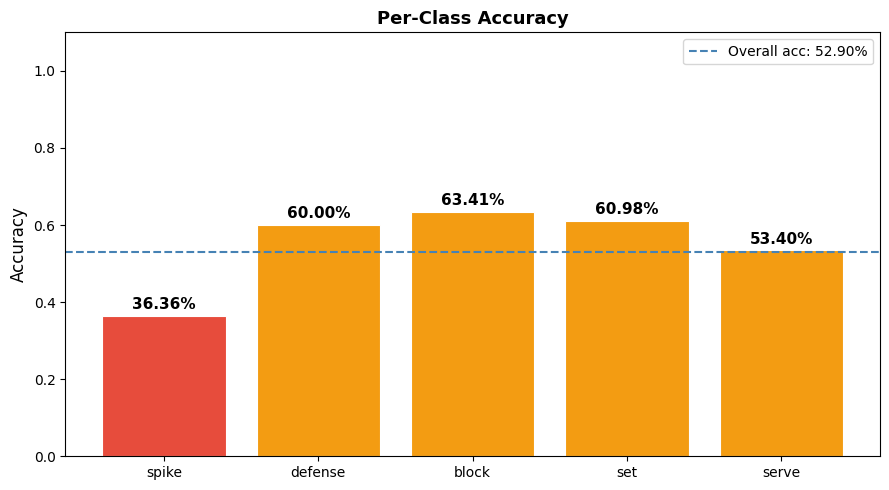

Saved → per_class_accuracy.png


In [9]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)

colors = ['#e74c3c' if a < 0.5 else '#f39c12' if a < 0.7 else '#2ecc71'
          for a in per_class_acc]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(CLASS_NAMES, per_class_acc, color=colors, edgecolor='white', linewidth=0.8)

for bar, acc in zip(bars, per_class_acc):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{acc:.2%}', ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

ax.axhline(accuracy, color='steelblue', linestyle='--', linewidth=1.5,
           label=f'Overall acc: {accuracy:.2%}')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Per-Class Accuracy', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → per_class_accuracy.png')

## Confidence Distribution

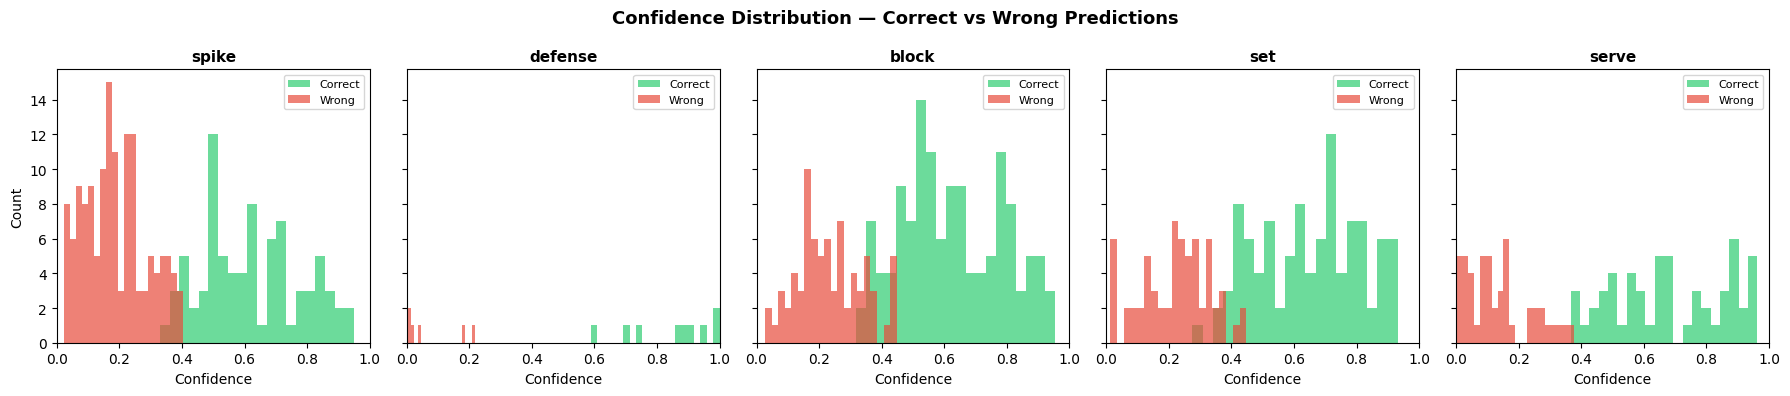

Saved → confidence_dist.png


In [10]:
fig, axes = plt.subplots(1, len(CLASS_NAMES), figsize=(18, 4), sharey=True)

for i, (cls, ax) in enumerate(zip(CLASS_NAMES, axes)):
    mask = all_labels == i
    if mask.sum() == 0:
        ax.set_title(f'{cls}\n(no samples)')
        continue

    correct_conf   = all_probs[mask & (all_preds == all_labels), i]
    incorrect_conf = all_probs[mask & (all_preds != all_labels), i]

    ax.hist(correct_conf,   bins=20, alpha=0.7, color='#2ecc71', label='Correct')
    ax.hist(incorrect_conf, bins=20, alpha=0.7, color='#e74c3c', label='Wrong')
    ax.set_title(f'{cls}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Confidence')
    ax.set_xlim(0, 1)
    if i == 0:
        ax.set_ylabel('Count')
    ax.legend(fontsize=8)

fig.suptitle('Confidence Distribution — Correct vs Wrong Predictions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confidence_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → confidence_dist.png')

## Threshold Analysis
How accuracy and coverage change as you raise the confidence threshold (matches the `CONFIDENCE_THRESHOLD` used in video inference).

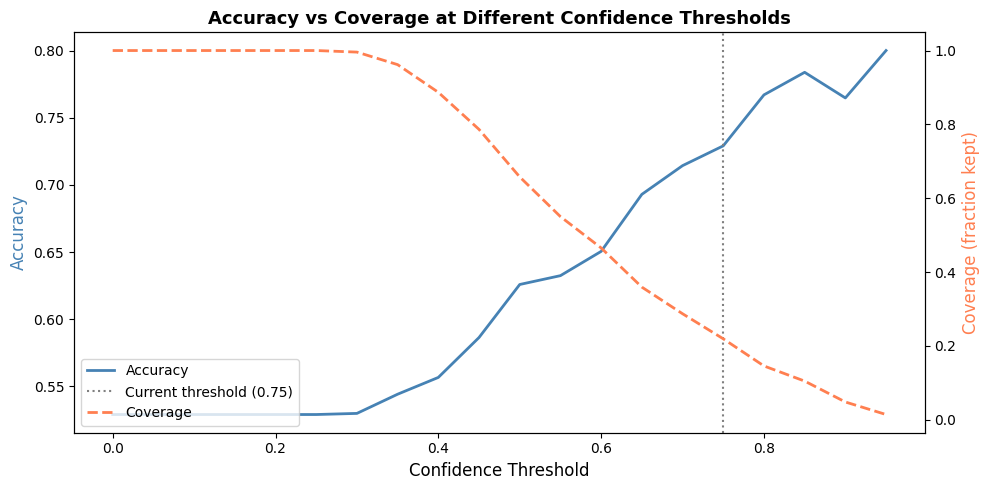

Saved → threshold_analysis.png


In [11]:
thresholds = np.arange(0.0, 1.0, 0.05)
accs, coverages = [], []

max_confs = all_probs.max(axis=1)

for t in thresholds:
    mask = max_confs >= t
    if mask.sum() == 0:
        accs.append(np.nan)
        coverages.append(0.0)
    else:
        accs.append((all_preds[mask] == all_labels[mask]).mean())
        coverages.append(mask.mean())

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.plot(thresholds, accs,       color='steelblue', linewidth=2, label='Accuracy')
ax2.plot(thresholds, coverages,  color='coral',     linewidth=2, linestyle='--', label='Coverage')

ax1.axvline(0.75, color='gray', linestyle=':', linewidth=1.5, label='Current threshold (0.75)')

ax1.set_xlabel('Confidence Threshold', fontsize=12)
ax1.set_ylabel('Accuracy', color='steelblue', fontsize=12)
ax2.set_ylabel('Coverage (fraction kept)', color='coral', fontsize=12)
ax1.set_title('Accuracy vs Coverage at Different Confidence Thresholds', fontsize=13, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left')

plt.tight_layout()
plt.savefig('threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → threshold_analysis.png')

## Summary

In [12]:
print('=' * 45)
print(f'  Checkpoint : {CHECKPOINT}')
print(f'  Test set   : {len(test_dataset)} samples')
print(f'  Overall Acc: {accuracy:.4f} ({accuracy*100:.2f}%)')
print()
print('  Per-class accuracy:')
for name, acc in zip(CLASS_NAMES, per_class_acc):
    flag = '✅' if acc >= 0.7 else '⚠️ ' if acc >= 0.5 else '❌'
    print(f'    {flag} {name:<10} {acc:.2%}')
print('=' * 45)

  Checkpoint : pose_classifier_best.pt
  Test set   : 707 samples
  Overall Acc: 0.5290 (52.90%)

  Per-class accuracy:
    ❌ spike      36.36%
    ⚠️  defense    60.00%
    ⚠️  block      63.41%
    ⚠️  set        60.98%
    ⚠️  serve      53.40%
